In [98]:
import torch
from torch import nn
from collections import defaultdict
torch.manual_seed(1)

class SmallNetwork(nn.Module):
    def __init__(self, l2i, l3i, l4i):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(5, l2i),
            nn.ReLU(),
            nn.Linear(l2i, l3i),
            nn.ReLU(),
            nn.Linear(l3i, l4i),
            nn.ReLU(),
            nn.Linear(l4i, 1),
        )

    def forward(self, x):
        return self.linear_relu_stack(x)

model = SmallNetwork(4,3,2)

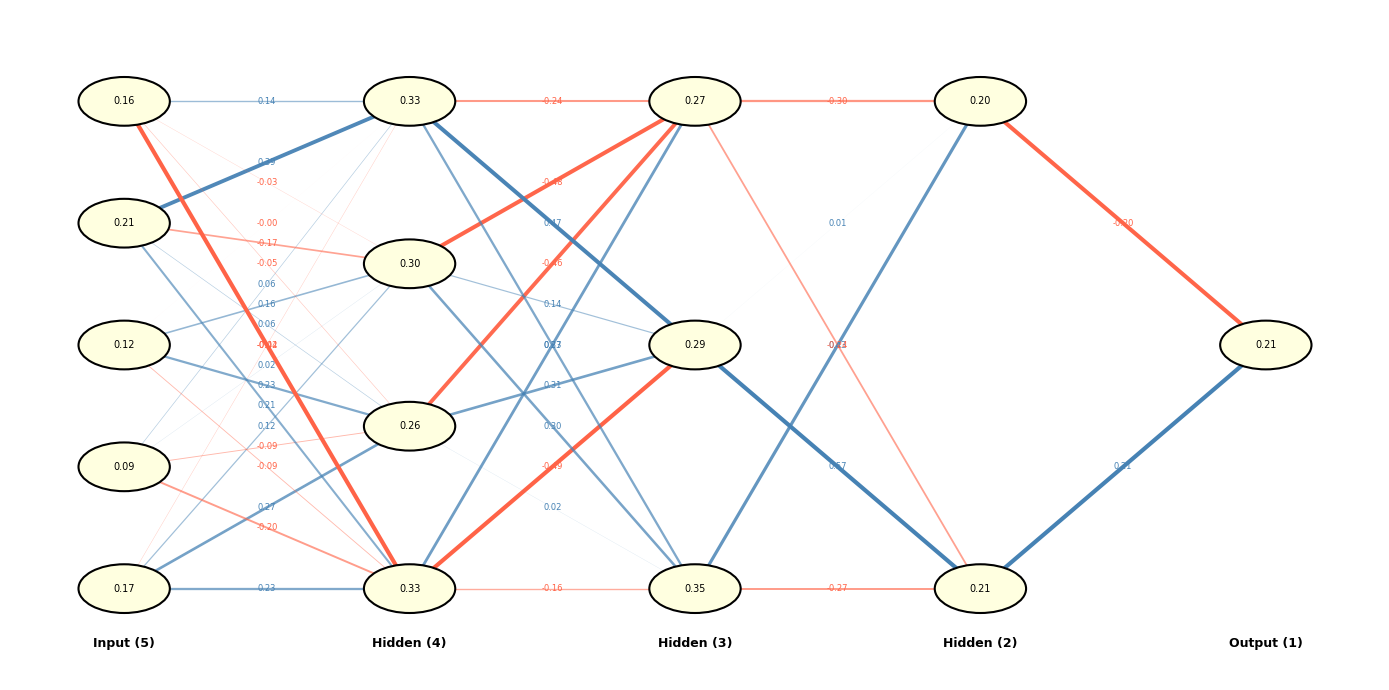

In [99]:
def draw_network(model, figsize=(14, 7)):
    linear_layers = [m for m in model.linear_relu_stack if isinstance(m, nn.Linear)]
    weights = [l.weight.data.numpy() for l in linear_layers]

    layer_sizes = [weights[0].shape[1]] + [w.shape[0] for w in weights]
    n_layers = len(layer_sizes)

    importance = []
    importance.append(np.abs(weights[0]).mean(axis=0))
    for l in range(1, len(weights)):
        importance.append(np.abs(weights[l]).mean(axis=0))
    importance.append(np.abs(weights[-1]).mean(axis=1))

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.05, 1.05)
    ax.axis('off')

    node_pos = []
    for i, size in enumerate(layer_sizes):
        x = i / (n_layers - 1)
        ys = np.linspace(0.1, 0.9, size) if size > 1 else [0.5]
        node_pos.append([(x, y) for y in ys])

    # edges
    for l, W in enumerate(weights):
        vmax = np.abs(W).max()
        for j, (x1, y1) in enumerate(node_pos[l]):
            for k, (x2, y2) in enumerate(node_pos[l + 1]):
                w = W[k, j]
                color = 'steelblue' if w > 0 else 'tomato'
                lw = abs(w) / vmax * 3
                alpha = 0.3 + 0.7 * abs(w) / vmax
                ax.plot([x1, x2], [y1, y2], color=color, lw=lw, alpha=alpha, zorder=1)
                mx, my = (x1 + x2) / 2, (y1 + y2) / 2
                ax.text(mx, my, f'{w:.2f}', fontsize=6, ha='center', va='center', color=color, zorder=2)

    # nodes with importance scores
    for i, (layer, imp) in enumerate(zip(node_pos, importance)):
        for j, (x, y) in enumerate(layer):
            ax.add_patch(mpatches.Circle((x, y), 0.04, color='lightyellow', ec='black', lw=1.5, zorder=3))
            ax.text(x, y, f'{imp[j]:.2f}', fontsize=7, ha='center', va='center', zorder=4)

    # layer labels
    names = ['Input (5)'] + [f'Hidden ({s})' for s in layer_sizes[1:-1]] + ['Output (1)']
    for name, layer in zip(names, node_pos):
        ax.text(layer[0][0], 0.02, name, ha='center', va='top', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

draw_network(model)


In [100]:
linear_layers = [(i, m) for i, m in enumerate(model.linear_relu_stack) if isinstance(m, nn.Linear)]

saved = [[layer.weight.data.clone(), layer.bias.data.clone()] 
         for _, layer in linear_layers]

def remove(saved, layer, node):
    # remove row from current layer weight
    saved[layer-1][0] = torch.cat([saved[layer-1][0][:node], saved[layer-1][0][node+1:]], dim=0)
    # remove element from current layer bias
    saved[layer-1][1] = torch.cat([saved[layer-1][1][:node], saved[layer-1][1][node+1:]])
    # remove column from next layer weight
    saved[layer][0] = torch.cat([saved[layer][0][:, :node], saved[layer][0][:, node+1:]], dim=1)

def leastweight(saved):
    layer = 0
    node = 0
    v = torch.inf
    for l in range(1,len(saved)):
        importance = saved[l][0].abs().sum(dim=0)
        print(importance)
        if v >= min(importance).item():
            v = min(importance).item()
            layer = l
            node = importance.argmin().item()
    return layer, node

def removeT(saved, removals):
    by_layer = defaultdict(set)
    for layer, node in removals:
        by_layer[layer].add(node)

    for layer, nodes in by_layer.items():
        keep = [i for i in range(saved[layer - 1][0].shape[0]) if i not in nodes]
        saved[layer - 1][0] = saved[layer - 1][0][keep]
        saved[layer - 1][1] = saved[layer - 1][1][keep]
        saved[layer][0]     = saved[layer][0][:, keep]

def leastweightRank(saved, minimum):
    rankings = []
    for l in range(1, len(saved)):
        importance = saved[l][0].abs().mean(dim=0)
        print(importance)
        for k, score in enumerate(importance):
            rankings.append((score.item(), l, k))

    rankings.sort(key=lambda x: x[0])

    layer_counts = {l: saved[l][0].shape[1] for l in range(1, len(saved))}
    result = []
    for score, l, k in rankings:
        if layer_counts[l] > minimum:
            result.append((l, k))
            layer_counts[l] -= 1

    return result


In [101]:
w = leastweightRank(saved, 1)
print(w)
print(len(w))


tensor([0.3263, 0.2632, 0.3044, 0.3291])
tensor([0.3506, 0.2867, 0.2742])
tensor([0.2080, 0.2042])
[(3, 1), (1, 1), (2, 2), (2, 1), (1, 2), (1, 0)]
6


In [102]:
removeT(saved, w[:2])
print(saved[0][0].shape[0], saved[1][0].shape[0], saved[2][0].shape[0])
w = leastweightRank(saved, 1)

3 3 1
tensor([0.3263, 0.3044, 0.3291])
tensor([0.2683, 0.5665, 0.2443])
tensor([0.2080])


In [103]:
l2i = saved[1][0].shape[0]  # out_features of layer 0
l3i = saved[2][0].shape[0]  # out_features of layer 1
l4i = saved[3][0].shape[0]  # out_features of layer 2

new_model = SmallNetwork(l2i, l3i, l4i)
new_linear_layers = [(i, m) for i, m in enumerate(new_model.linear_relu_stack) if isinstance(m, nn.Linear)]

for (w, b), (_, layer) in zip(saved, new_linear_layers):
    layer.weight.data = w.clone()
    layer.bias.data   = b.clone()

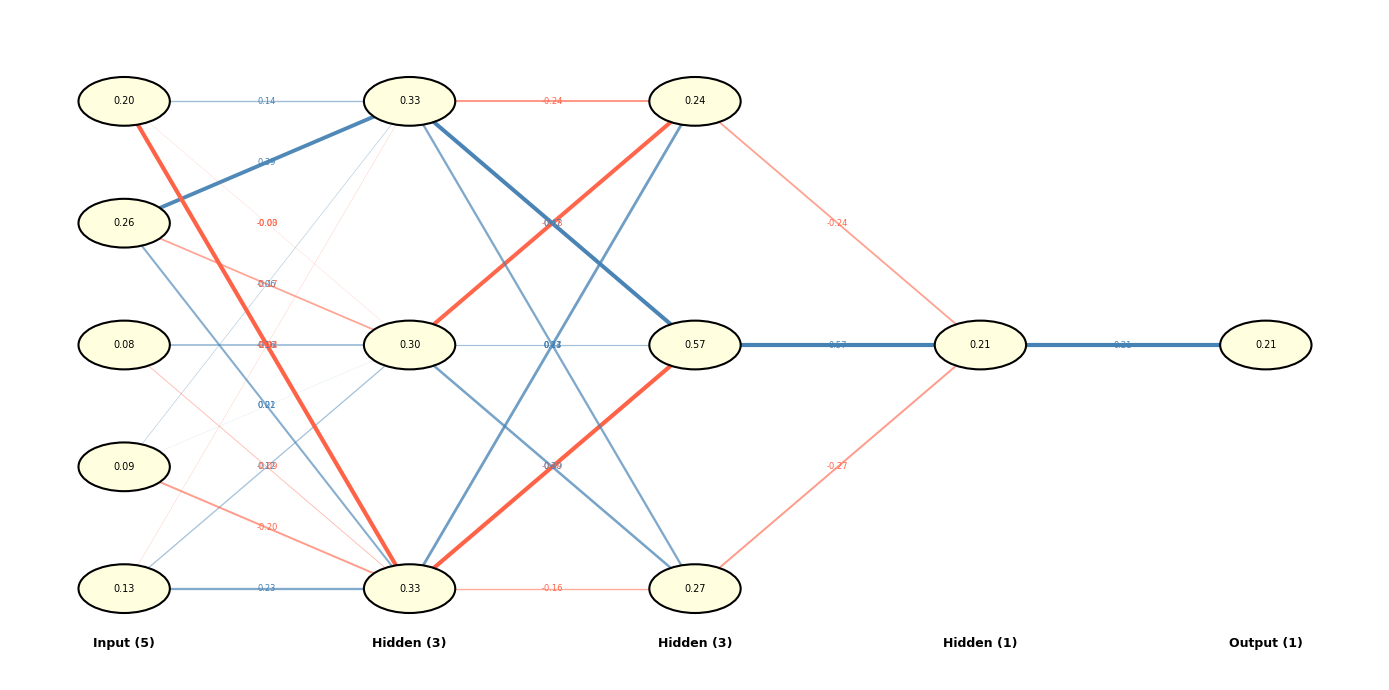

In [104]:
draw_network(new_model)

In [105]:
ll = [(i, m) for i, m in enumerate(new_model.linear_relu_stack) if isinstance(m, nn.Linear)]

saved2 = [[layer.weight.data.clone(), layer.bias.data.clone()] 
         for _, layer in ll]

leastweightRank(saved2,1 )

tensor([0.3263, 0.3044, 0.3291])
tensor([0.2683, 0.5665, 0.2443])
tensor([0.2080])


[(2, 2), (2, 0), (1, 1), (1, 0)]